Verify that the data of your personal project have at least 2 continuous and 2 categorical or discrete variables. 
Otherwise change data.
With your data, proceed to the three analyses you did during the tutorial 1.

Understand data as actual values of random variables; Choose 2 variables of your project and make a probability model of them by assuming that each observation has been obtained by a simple random sampling (i.e. by drawing units uniformly with replacement in the population). Display a frequency table for your variables. Give explicitly the random variables involved and their expression in terms of your sample. What is the joint distribution of the frequencies displayed in the table ? 

The size of the sample, the number of classes and the notations must be clear. 
Proceed to a simple regression with 2 CONTINUOUS variables of your dataset. In this first part, you will write the model with all the assumptions (theoretical results must be written as a markdown), continue with the estimation of parameters, the regression line with all the necessary plots, CI for the prediction and the mean prediction. Outliers and residual analysis must be included. Make a decision about outliers (keep them or erase them from the set). 

Proceed to an analysis of variance with 1 DISCRETE or CATEGORICAL variable as input and 1 CONTINUOUS variables as output in your project.
Interpret and comment all your results.

In [64]:
import numpy as np
import scipy.stats as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv('spotify.csv')
df

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [66]:
#sns.pairplot(df.sample(n=300))

In [67]:

corrcoef_table = df[["popularity","duration_ms","danceability","energy","loudness","speechiness","acousticness","liveness","valence","tempo"]].corr()

strong_corr = corrcoef_table.where((corrcoef_table > 0.6) | (corrcoef_table < -0.6))
strong_corr

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,liveness,valence,tempo
popularity,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_ms,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy,NaN,NaN,NaN,1.000000,0.76169,NaN,-0.733906,NaN,NaN,NaN
loudness,NaN,NaN,NaN,0.761690,1.00000,NaN,NaN,NaN,NaN,NaN
speechiness,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
acousticness,NaN,NaN,NaN,-0.733906,NaN,NaN,1.000000,NaN,NaN,NaN
liveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
valence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
tempo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


from this table , we can see that the only values that have a supposed correlation are :
energy/loudness & energy/acousticnesss –––––––––––– So we'll keep those 

### Data cleaning time, were only going to keep the track info and two categorical and three numerical variables 
here we decided to chose :
#### 3 numerical continuous variables
- **energy** : Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale

- **loudness** : The overall loudness of a track in decibels (dB)

- **acousticness** : A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic

#### 2 categorical variables
- **key** : The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1

- **track_genre** : The genre in which the track belongs


--- *source : kaggle description of the dataset* ---

### Making the dataset less big 
we have a little problem , if we try to find correlations right now we encounter 2 subproblems :
1. Because there is 114k rows the calculations are very costly
2. Because there are so much values if we plot anything we will not be able to see any correlation

SO we sample n = 1000

In [68]:
spotify = df[["artists","album_name","track_name","energy","loudness","acousticness","key","track_genre"]]
spotify = spotify.sample(n=1000) 
spotify = spotify.reset_index()
spotify = spotify.drop("index",axis=1)
spotify

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
0,Kranium;Ty Dolla $ign;Wizkid,Can't Believe (feat. Ty Dolla $ign & WizKid),Can't Believe (feat. Ty Dolla $ign & WizKid),0.764,-4.893,0.00117,6,dancehall
1,Alphaxone,Ghost Machine,Dissociative,0.104,-27.259,0.60700,10,iranian
2,Da'ville,To Jireh,To Jireh,0.584,-6.230,0.01680,9,dancehall
3,Avicii,Обратно в клас - pop,Wake Me Up - Radio Edit,0.807,-4.160,0.00415,2,dance
4,Hania Rani;Dobrawa Czocher,The Best Classical Playlist,There Will Be Hope,0.211,-20.438,0.97100,2,classical
...,...,...,...,...,...,...,...,...
995,Bruno Mars;Anderson .Paak;Silk Sonic,Pop Hits Now,Love's Train,0.625,-9.008,0.02900,6,pop
996,Katinguelê,No compasso do criador,No compasso do criador,0.500,-13.551,0.40500,5,pagode
997,Vander Lee,Vander Lee (Ao vivo),Contra o tempo - Ao vivo,0.509,-8.242,0.76500,7,mpb
998,12 Stones,Anthem For The Underdog (Bonus Track Version),World So Cold,0.688,-4.949,0.47200,4,grunge


c:\Users\zix\anaconda3\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


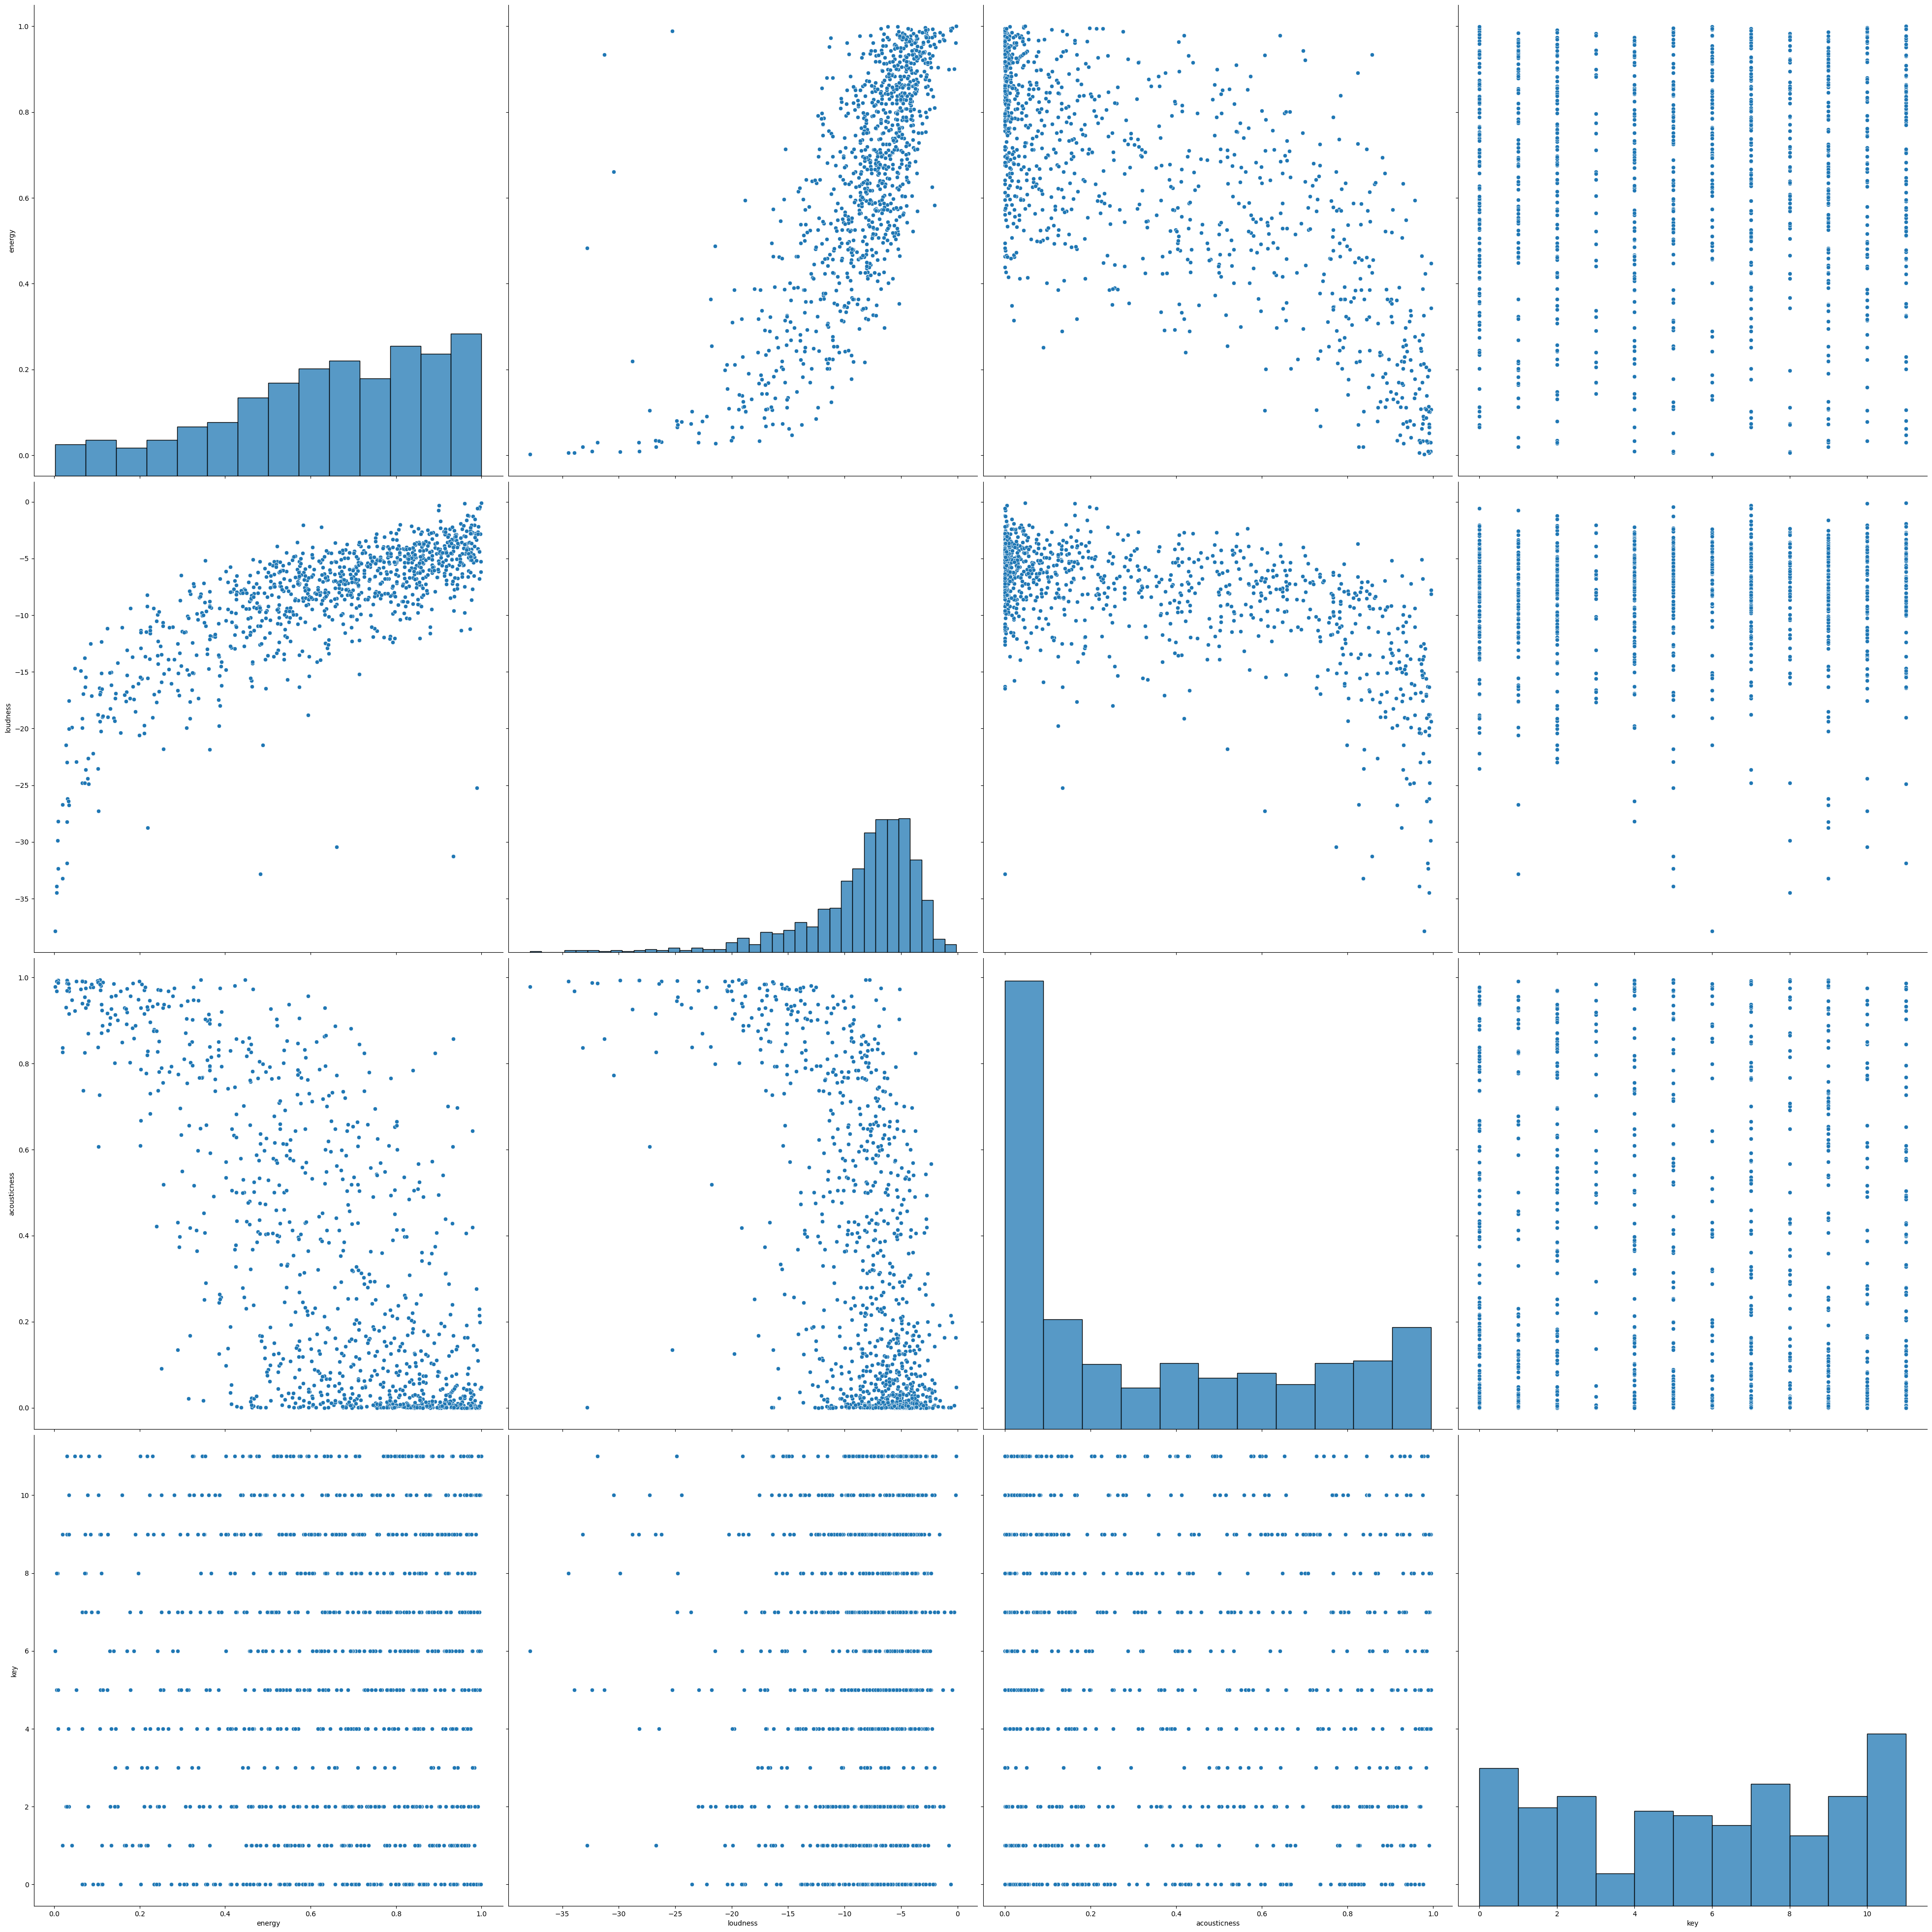

In [69]:
#fig , ax = plt.subplots(figsize =(10,7),dpi=100)
spotify.iloc[:,3:]
sns.pairplot(spotify.iloc[:,3:],size=10)

 We can observe an exponential relation in between loudness & energy, so if we linearise the model we might just find a lienar model 

# LINEAR REGRESSION - hell yeah
1. linearization
2. linear regression

<Axes: xlabel='loudness', ylabel='energy'>

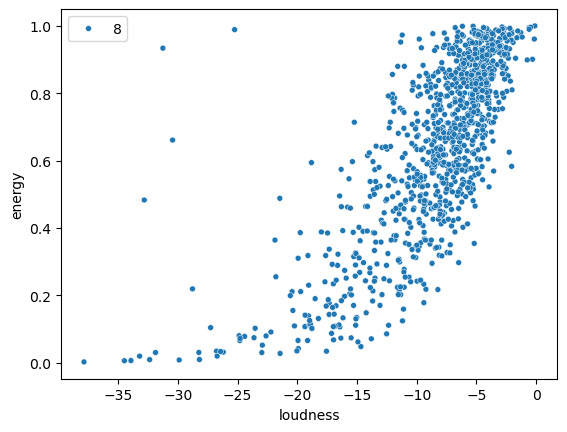

In [70]:
spotify_lr = spotify[["loudness","energy"]] # first we only take the two 
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size=8)

In [71]:
np.corrcoef(x=spotify_lr.loudness,y=spotify_lr.energy)

array([[1.        , 0.74950071],
       [0.74950071, 1.        ]])

# LINEARIZATION ( we tried but it didn't work)

**1. Linearisation**

In [72]:
# to linearise , we'll apply a map to the y value
spotify_linearized = pd.DataFrame()
spotify_linearized['loudness'] = spotify_lr["loudness"]
spotify_linearized["energy"] = spotify_lr["energy"].map(np.log)
spotify_linearized


,loudness,energy
0,-4.893,-0.269187
1,-27.259,-2.263364
2,-6.230,-0.537854
3,-4.160,-0.214432
4,-20.438,-1.555897
...,...,...
995,-9.008,-0.470004
996,-13.551,-0.693147
997,-8.242,-0.675307
998,-4.949,-0.373966


In [73]:
# removing the outlier 
spotify_linearized = spotify_linearized.where(spotify_linearized > -10)
spotify_linearized = spotify_linearized.dropna()
spotify_linearized

,loudness,energy
0,-4.893,-0.269187
2,-6.230,-0.537854
3,-4.160,-0.214432
5,-6.203,-0.155485
7,-2.664,-0.008032
...,...,...
994,-4.328,-0.155485
995,-9.008,-0.470004
997,-8.242,-0.675307
998,-4.949,-0.373966


array([[1.        , 0.56073533],
       [0.56073533, 1.        ]])

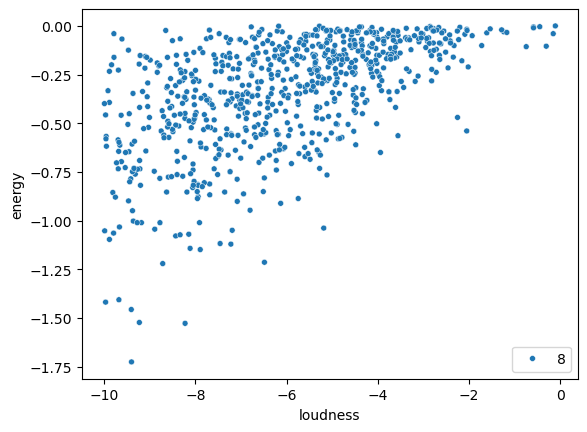

In [74]:
sns.scatterplot(data=spotify_linearized,x='loudness',y='energy',size = 8)
np.corrcoef(spotify_linearized.energy,spotify_linearized.loudness)
# hey , the corr coefficient is 0.8 , it's good 


# CONTINUE HERE

**2. Start of Linear Regression**

In [75]:
lr = st.linregress(x=spotify_lr.loudness,y=spotify_lr.energy)
a = lr.intercept
b = lr.slope
coef = [b,a]
boundaries = [-30,0]
hy=a+b*spotify_lr.loudness
e= spotify_lr.energy-hy
sse= np.sum(e**2)
hs2=sse/(n-2)
lr


LinregressResult(slope=np.float64(0.03621436083512288), intercept=np.float64(0.9464093421310706), rvalue=np.float64(0.7495007107582646), pvalue=np.float64(5.568596848019832e-181), stderr=np.float64(0.001012520477945635), intercept_stderr=np.float64(0.010164489604477035))

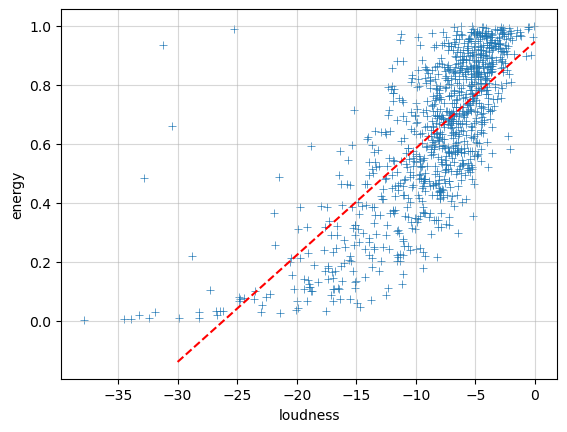

In [76]:
# lets plot this 
line = np.poly1d(coef)
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',marker="+")
plt.plot(boundaries,line(boundaries),'r--')
plt.grid(alpha = 0.5)


## outliers ? 

C:\Users\zix\AppData\Local\Temp\ipykernel_17092\1594163730.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(z,line(z)+ 2*np.sqrt(hs2),'b-',linestyle='dashed',linewidth = 0.7)
C:\Users\zix\AppData\Local\Temp\ipykernel_17092\1594163730.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(z,line(z)- 2*np.sqrt(hs2),'b-', linestyle='dashed',linewidth = 0.7)


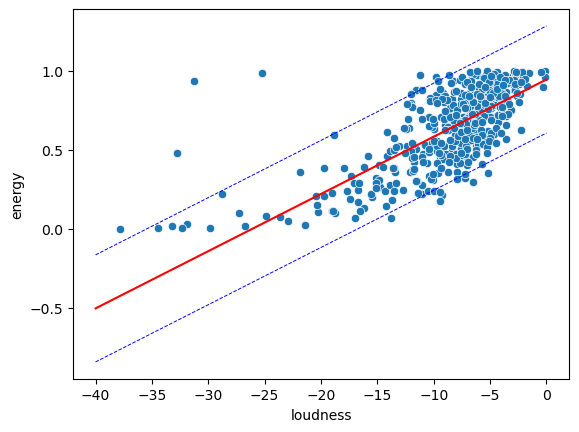

In [77]:
z = [-40,0]
sns.scatterplot(data=spotify.sample(500) , x="loudness" , y="energy" ,markers="*")


plt.plot(z,line(z),'r-')
plt.plot(z,line(z)+ 2*np.sqrt(hs2),'b-',linestyle='dashed',linewidth = 0.7)
plt.plot(z,line(z)- 2*np.sqrt(hs2),'b-', linestyle='dashed',linewidth = 0.7)

<Axes: xlabel='loudness', ylabel='energy'>

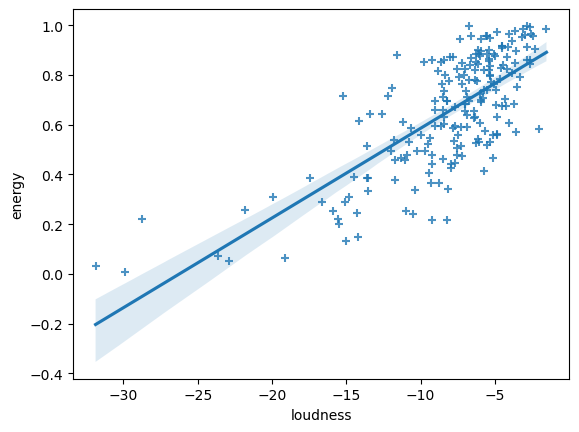

In [78]:
sns.regplot(data=spotify.sample(200),x='loudness',y='energy',marker='+')

### continum analysis

In [79]:
x = spotify_lr.loudness
y = spotify_lr.energy
n = len(spotify_lr.loudness)

hy = a+b*x
e = y - hy

sse = np.sum(e**2)
hs2 = sse/(n-2)

residual analysis

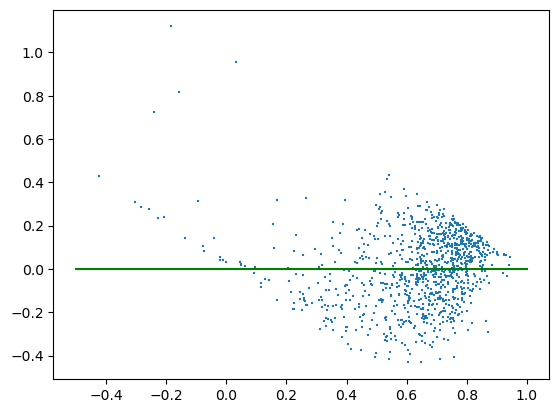

In [80]:
plt.scatter(x=hy,y=e,marker="+",s= 4)
plt.plot([-0.5,1],[0,0],'g')

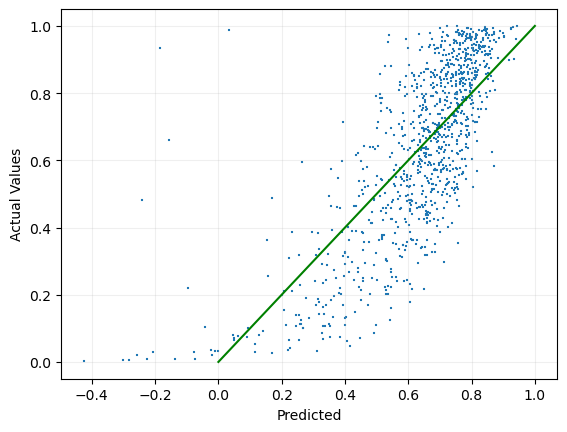

In [81]:
plt.scatter(x=hy,y=y,marker="+",s=7-5)
plt.plot([0,1],[0,1],'g')
plt.xlabel('Predicted')
plt.ylabel('Actual Values')
plt.grid(visible=True,alpha=0.2)

### q-q plot

In [82]:
dist = st.norm(loc=0,scale=np.sqrt(hs2))

Text(0.5, 1.0, 'q-q plot')

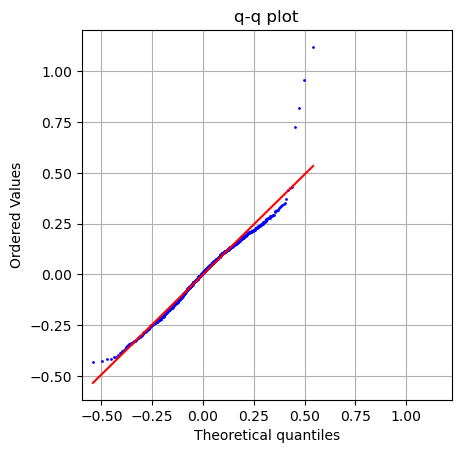

In [83]:
st.probplot(e,dist=dist,plot=plt)
plt.gca().lines[0].set_markersize(1)
plt.axis('square')
plt.grid()
plt.title("q-q plot")

**INterpratation** : the q-q plot is fine , however the residuals express heteroscadisticity , maybe they just have different sigmas. So technically we cannot apply our linear regression

# Anova regression

Proceed to an analysis of variance with 1 DISCRETE or CATEGORICAL variable as input and 1 CONTINUOUS variables as output in your project.
Interpret and comment all your results.

We take the categorical variable of the genre , and the continuous one being the energy 
We also chose 9 genres to make the analysis simpler 

In [84]:
# Only choosing some categories
types_list = ['house','r-n-b','jazz','brazil','emo','acoustic','latino','drum-and-bass','opera']
spotify_Anova = spotify[spotify['track_genre'].isin(types_list)]
spotify_Anova

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
10,Jubël,Hits Hits Hits,So Sick,0.750,-6.636,0.294000,3,house
17,Daddy Yankee;Snow,pov: it's 2019,Con Calma,0.860,-2.652,0.110000,8,latino
38,Camo & Krooked;Mira Lu Kovacs,No Way Out (feat. Mira Lu Kovacs),No Way Out (feat. Mira Lu Kovacs),0.901,-0.308,0.005360,7,drum-and-bass
45,Caravan Palace,<I°_°I>,Aftermath,0.663,-7.105,0.230000,8,jazz
63,Magdalena Fleitas,Risas Del Agua,De quién son esos ojitos,0.106,-16.431,0.727000,11,latino
...,...,...,...,...,...,...,...,...
936,Marcelo Falcão;Cynthia Luz,Sexta-Feira,Sexta-Feira,0.739,-5.548,0.065000,6,brazil
939,Brennan Savage,Badlands,Lonely World,0.670,-7.009,0.012400,4,emo
946,A.M.C,ENERGY,Reanimate,0.990,-0.587,0.000133,7,drum-and-bass
974,Wet Wet Wet,90's Music Grandi Successi,"Love Is All Around - From ""Four Weddings And A...",0.744,-5.222,0.242000,10,r-n-b


In [85]:
spotify_Anova = spotify_Anova[['track_genre','energy']]
spotify_Anova

,track_genre,energy
10,house,0.750
17,latino,0.860
38,drum-and-bass,0.901
45,jazz,0.663
63,latino,0.106
...,...,...
936,brazil,0.739
939,emo,0.670
946,drum-and-bass,0.990
974,r-n-b,0.744


<Axes: xlabel='track_genre', ylabel='energy'>

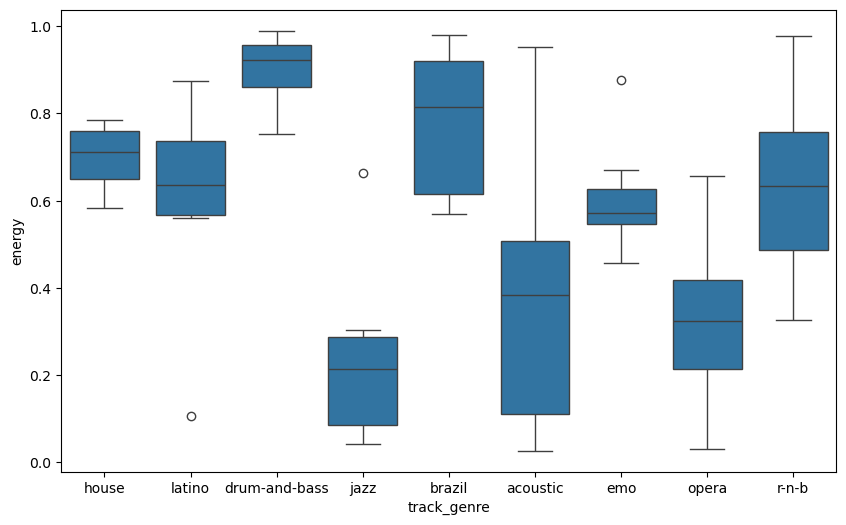

In [86]:
# BOxplottts 
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=spotify_Anova, x="track_genre", y="energy", ax=ax)


Hey , there seems to be a good difference in between types  , and also some that maybe are very similar ( for example drum&Bass and house that are very similar in style so it's not suprising that they have similar boxplots )

## analysis of variance

In [87]:
spotify_Anova.groupby('track_genre').describe()

energy                                                        \
               count      mean       std     min      25%     50%      75%   
track_genre                                                                  
acoustic         9.0  0.402222  0.329821  0.0273  0.11100  0.3840  0.50700   
brazil           6.0  0.780833  0.180886  0.5700  0.61525  0.8140  0.92125   
drum-and-bass    8.0  0.895250  0.092671  0.7520  0.86100  0.9230  0.95800   
emo              7.0  0.607143  0.134923  0.4570  0.54600  0.5720  0.62650   
house            4.0  0.697500  0.089765  0.5830  0.64975  0.7110  0.75875   
jazz             7.0  0.238057  0.212756  0.0417  0.08685  0.2150  0.28650   
latino           8.0  0.617125  0.239343  0.1060  0.56675  0.6365  0.73625   
opera           12.0  0.336325  0.188146  0.0299  0.21400  0.3245  0.41775   
r-n-b            8.0  0.635000  0.211222  0.3270  0.48775  0.6340  0.75850   

                      
                 max  
track_genre           
acoustic       0.953  
brazil         0.981  
drum-and-bass  0.990  
emo            0.876  
house          0.785  
jazz           0.663  
latino         0.874  
opera          0.657  
r-n-b          0.978

#### with an scipy stats function

In [88]:
groups = [g["energy"].to_numpy()for _, g in spotify_Anova.groupby("track_genre")]

anova = st.f_oneway(groups[0],groups[1],groups[2],groups[3],groups[4],groups[5],groups[6],groups[7],groups[8])
print(f"the d statistic is {anova.statistic} with p-value {anova.pvalue}")
print(f" the statistic is very high and p-value is very low so we can conclude that the track genre does impact energy , we reject H_O")

the d statistic is 8.364384205437633 with p-value 1.5141834621847483e-07
 the statistic is very high and p-value is very low so we can conclude that the track genre does impact energy , we reject H_O


# FULL ANOVA REGRESSION

In [106]:
y = [list(g["energy"])  for _, g in spotify_Anova.groupby("track_genre")]
y = pd.DataFrame(y)
y

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.111,0.839,0.384,0.0477,0.953,0.0273,0.507,0.297,0.454,NaN,NaN,NaN
1,0.981,0.574,0.570,0.9320,0.889,0.7390,NaN,NaN,NaN,NaN,NaN,NaN
2,0.901,0.945,0.752,0.7560,0.967,0.8960,0.955,0.990,NaN,NaN,NaN,NaN
3,0.522,0.570,0.583,0.5720,0.876,0.4570,0.670,NaN,NaN,NaN,NaN,NaN
4,0.750,0.583,0.785,0.6720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.663,0.108,0.215,0.0417,0.269,0.0657,0.304,NaN,NaN,NaN,NaN,NaN
6,0.860,0.106,0.874,0.5600,0.671,0.6950,0.569,0.602,NaN,NaN,NaN,NaN
7,0.205,0.347,0.277,0.2170,0.337,0.6480,0.312,0.657,0.402,0.139,0.465,0.0299
8,0.978,0.327,0.557,0.4660,0.711,0.8020,0.495,0.744,NaN,NaN,NaN,NaN


In [107]:
def fisher_exo2(df):
    k = df.shape[1]
    ni = df.notna().sum()
    n = np.sum(ni)
    yib = df.mean()
    yb = df.mean(axis = None) # tells pandas that the summation is not in respect to the same axis
    ssm = np.sum(ni*(yib-yb)**2)
    sse = ((df-yib)**2).mean(axis=None)*n
    f = (ssm/(k-1))/(sse/(n-k))
    p = st.f.sf(k,k-1,n-k)
    return k,ni,yib,yb,ssm,sse,f,p



In [110]:
k,ni,yib,yb,ssm,sse,f,p = fisher_exo2(y)
print(yib)
print(p)

0     0.663444
1     0.488778
2     0.555222
3     0.473822
4     0.709125
5     0.541250
6     0.544571
7     0.658000
8     0.428000
9     0.139000
10    0.465000
11    0.029900
dtype: float64
3.142072911118661e-11


We do not reject because p-value<0.05
